# Stitching redesign, step 1: measure every edge

For every pair of 4-connected neighbour FOVs (an *edge*), find where the
neighbour really sits relative to the anchor, from the bead frame of the
cells round.

**What is new vs. `camera_rotation.register_neighbor_pair`**: the displacement
is computed from the crop geometry (frame - crop width + shift), not as
`nominal + shift`. The old form silently assumed the crop width equals the
nominal overlap; on 2026-08-13 MF3's pixel size was hard-coded as 0.108 um
(MERlin's JSON says 0.109), the crop came out 205 px instead of ~222 px, and
every cached edge got a constant along-axis bias. Section 5 measures it.

Data: BC555_sample_05/epi (MF3, 476 FOVs). The calculation section reads the
live experiment once and writes everything later steps need to `DATA_DIR`.

In [1]:
import os, sys, json, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection

# notebooks/tests/<subfolder>/ is three levels under the repo root.
MERCI_DIR = Path(os.getcwd()).parent.parent.parent
sys.path.insert(0, str(MERCI_DIR / "src"))
sys.path.insert(0, os.getcwd())
import stitching_redesign_lib as L

NOTEBOOK_NAME = "stitching_redesign_step_01_measure_edges"
# Local data copy shared by every stitching_redesign_step_NN notebook
# (written by step 01; source: BC555_sample_05/epi, cells round).
DATA_DIR = MERCI_DIR / "cache" / "2026_09_25_1336" / "stitching_redesign" / "data"
FIG_DIR = MERCI_DIR / "cache" / "2026_09_25_1336" / "explanation" / "figures" / NOTEBOOK_NAME
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TITLE_FS, LABEL_FS, TICK_FS, LEGEND_FS = 14, 12, 11, 10
plt.rcParams.update({"axes.titlesize": TITLE_FS, "axes.labelsize": LABEL_FS,
                     "xtick.labelsize": TICK_FS, "ytick.labelsize": TICK_FS,
                     "legend.fontsize": LEGEND_FS})
DIR_COLORS = {"right": "#1f77b4", "left": "#ff7f0e", "up": "#2ca02c", "down": "#d62728"}


def save(fig, stem):
    path = FIG_DIR / f"{stem}.png"
    fig.savefig(path, dpi=110, bbox_inches="tight")
    print("saved", path.relative_to(MERCI_DIR))


## 1 — Parameters

In [2]:
SOURCE_DIR = Path("/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi")
POSITIONS_FILE = SOURCE_DIR / "positions" / "positions_BC555_sample_05_epi.txt"
CELLS_PATTERN = "data/cells/hal-mf3-cells_{fov:03d}.zarr"
# Cached edges from notebooks/tests/fov_stitching/02_compare_stitching_correction_methods
OLD_EDGES_FILE = SOURCE_DIR / "analysis" / "cache" / "compare_stitching_correction_methods" / "correspondences.csv"

BEAD_FRAME = 0                      # frame table: frame 0 = 488 nm fiducial beads
DAPI_FRAMES = list(range(1, 26))    # frame table: 405 nm, z 1..25 (display only)
UPSAMPLE = 10                       # phase-correlation precision: 1/10 px
FORCE_RECOMPUTE = False

## 2 — Geometry (from MERlin's microscope JSON + the positions file)

In [3]:
from scipy.spatial import cKDTree
from MERci.acquisition.merlin_config import load_microscope_parameters
from MERci.acquisition.configs import apply_microscope_orientation, get_camera_pixel_size_um, get_camera_frame_size

mp = load_microscope_parameters("MF3")
ORIENT = {k: bool(mp[k]) for k in ("transpose", "flip_horizontal", "flip_vertical")}
PX = float(get_camera_pixel_size_um("MF3"))
FRAME = int(get_camera_frame_size("MF3")[0])
nominal = np.loadtxt(POSITIONS_FILE, delimiter=",")
STEP = float(np.median(cKDTree(nominal).query(nominal, k=2)[0][:, 1]))
N_CROP = int(round(FRAME - STEP / PX))     # nominal overlap, px
print(f"pixel {PX} um, frame {FRAME} px ({FRAME * PX:.2f} um), step {STEP:.3f} um "
      f"(median nearest-neighbour distance), nominal overlap {N_CROP} px = {N_CROP * PX:.2f} um")
print("orientation", ORIENT)

# 3x3 neighbourhood: the FOV closest to the grid centroid with all 8 neighbours.
for cand in np.argsort(np.hypot(*(nominal - nominal.mean(0)).T)):
    NBHD = L.neighbourhood_ids(int(cand), nominal, STEP)
    if (NBHD >= 0).all():
        break
print("3x3 neighbourhood (row 0 = top):\n", NBHD)

shutil.copy(POSITIONS_FILE, DATA_DIR / "positions.txt")
shutil.copy(OLD_EDGES_FILE, DATA_DIR / "old_correspondences.csv")
(DATA_DIR / "geometry.json").write_text(json.dumps({
    "pixel_um": PX, "step_um": STEP, "frame_px": FRAME, "n_crop_px": N_CROP,
    "neighbourhood": NBHD.tolist(), "source": "BC555_sample_05/epi cells round"}, indent=1))

pixel 0.109 um, frame 2048 px (223.23 um), step 199.066 um (median nearest-neighbour distance), nominal overlap 222 px = 24.20 um
orientation {'transpose': True, 'flip_horizontal': False, 'flip_vertical': True}
3x3 neighbourhood (row 0 = top):
 [[202 222 239]
 [203 221 240]
 [204 220 241]]


256

## 3 — Calculation: measure every grid edge once (cached)

In [4]:
def load_frames(fov, frames):
    from MERci.common.io import read_image_frames
    raw = read_image_frames(SOURCE_DIR / CELLS_PATTERN.format(fov=fov), frames,
                            frame_width=FRAME, frame_height=FRAME)
    return [apply_microscope_orientation(f, **ORIENT) for f in raw]


gi, gj = L.grid_edges(nominal, STEP)
out_csv = DATA_DIR / "edges_remeasured.csv"
if out_csv.exists() and not FORCE_RECOMPUTE:
    new_df = pd.read_csv(out_csv)
    print(f"loaded {len(new_df)} cached edges")
else:
    cache, rows, t0 = {}, [], time.time()
    def bead(f):
        if f not in cache:
            cache[f] = load_frames(f, [BEAD_FRAME])[0]
        return cache[f]
    for k, (a, b) in enumerate(zip(gi, gj)):
        d = nominal[b] - nominal[a]
        direction = ("right" if d[0] > 0 else "left") if abs(d[0]) > abs(d[1]) else ("up" if d[1] > 0 else "down")
        dx, dy, rho = L.measure_edge(bead(a), bead(b), direction, N_CROP, PX, UPSAMPLE)
        rows.append(dict(anchor_fov=a, neighbor_fov=b, direction=direction,
                         nominal_x=nominal[b, 0], nominal_y=nominal[b, 1],
                         measured_x=nominal[a, 0] + dx, measured_y=nominal[a, 1] + dy, pearson=rho))
        if (k + 1) % 100 == 0 or k + 1 == len(gi):
            el = time.time() - t0
            print(f"  {k + 1}/{len(gi)} edges, {el:.0f}s elapsed, ETA {el / (k + 1) * (len(gi) - k - 1):.0f}s")
    new_df = pd.DataFrame(rows)
    new_df.to_csv(out_csv, index=False)
    # 3x3 neighbourhood frames for later rendering: beads + DAPI max projection
    arrays = {}
    for f in NBHD.ravel():
        arrays[f"beads_{f}"] = bead(int(f))
        arrays[f"dapi_{f}"] = np.max(load_frames(int(f), DAPI_FRAMES), axis=0)
    np.savez_compressed(DATA_DIR / "neighbourhood_frames.npz", **arrays)
    del cache
edges = L.Edges(new_df, nominal)
old_df = pd.read_csv(DATA_DIR / "old_correspondences.csv")
print(f"{len(new_df)} physical edges measured; old cache: {len(old_df)} rows (both ends)")

  100/894 edges, 33s elapsed, ETA 260s


  200/894 edges, 62s elapsed, ETA 216s


  300/894 edges, 98s elapsed, ETA 194s


  400/894 edges, 130s elapsed, ETA 160s


  500/894 edges, 178s elapsed, ETA 140s


  600/894 edges, 227s elapsed, ETA 111s


  700/894 edges, 266s elapsed, ETA 74s


  800/894 edges, 296s elapsed, ETA 35s


  894/894 edges, 337s elapsed, ETA 0s


894 physical edges measured; old cache: 1788 rows (both ends)


In [5]:
nb = np.load(DATA_DIR / "neighbourhood_frames.npz")
BEADS = {int(f): nb[f"beads_{f}"] for f in NBHD.ravel()}
DAPI = {int(f): nb[f"dapi_{f}"] for f in NBHD.ravel()}
PARITY = {int(NBHD[r, c]): (r + c) % 2 for r in range(3) for c in range(3)}
CTR = int(NBHD[1, 1])


def corner_views(position_sets, frames=BEADS, half_um=12.0):
    """Render the 4 corners of the centre FOV (where 4 tiles overlap) for
    each position set. Positions are re-referenced to the centre FOV so
    every panel shows the same place."""
    corners = {"up_left": (0, 1), "up_right": (1, 1), "down_left": (0, 0), "down_right": (1, 0)}
    fig, axes = plt.subplots(len(position_sets), 4, figsize=(16, 4.1 * len(position_sets)), squeeze=False)
    for r, (name, P) in enumerate(position_sets.items()):
        Q = P - P[CTR] + nominal[CTR]
        for c, (cname, (sx, sy)) in enumerate(corners.items()):
            # corner of the centre tile's overlap with its neighbours
            cx = nominal[CTR, 0] + (STEP + (FRAME * PX - STEP) / 2 if sx else (FRAME * PX - STEP) / 2)
            cy = nominal[CTR, 1] + (STEP + (FRAME * PX - STEP) / 2 if sy else (FRAME * PX - STEP) / 2)
            rgb, ext = L.render_tiles(frames, {f: (*Q[f], PARITY[f]) for f in frames}, PX,
                                      bounds=(cx - half_um, cy - half_um, cx + half_um, cy + half_um))
            ax = axes[r, c]
            ax.imshow(rgb, extent=ext, origin="lower", interpolation="nearest")
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0:
                ax.set_title(cname)
            if c == 0:
                ax.set_ylabel(name, fontsize=LABEL_FS + 2)
    return fig


## 4 — The 3x3 neighbourhood

Tiles are drawn at their **nominal** grid positions, alternating magenta and
green. Where two tiles overlap and agree, the image turns white; where they
disagree, the same structure appears twice, once in each colour.

saved cache/2026_09_25_1336/explanation/figures/stitching_redesign_step_01_measure_edges/nbhd_nominal_overview.png


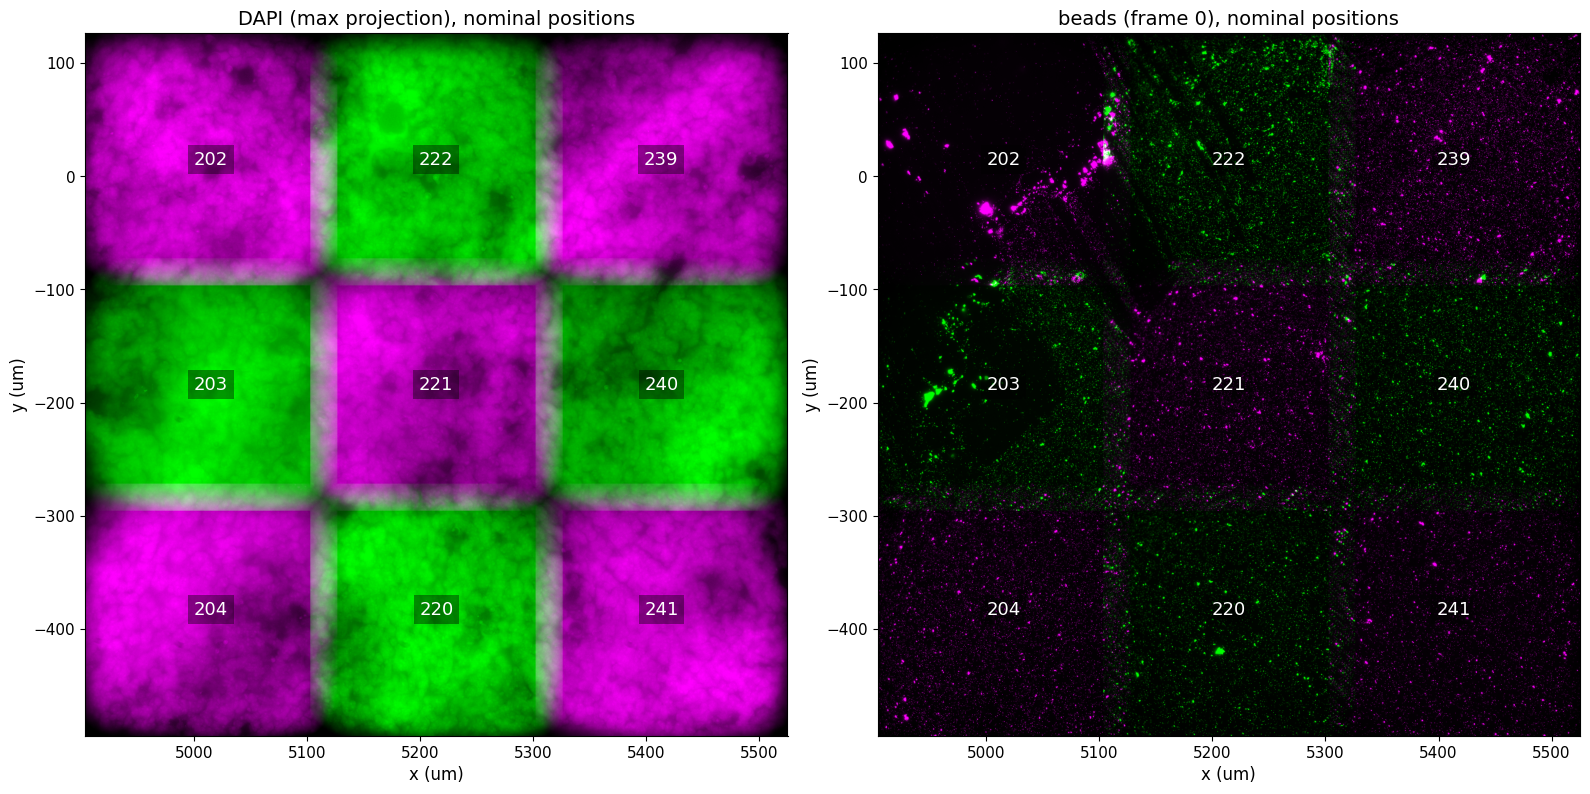

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
for a, (name, frames) in zip(ax, [("DAPI (max projection)", DAPI), ("beads (frame 0)", BEADS)]):
    rgb, ext = L.render_tiles(frames, {f: (*nominal[f], PARITY[f]) for f in frames}, PX)
    a.imshow(rgb[::4, ::4], extent=ext, origin="lower")
    for f in frames:
        a.text(*(nominal[f] + FRAME * PX / 2), str(f), color="w", fontsize=13, ha="center", va="center",
               bbox=dict(fc="k", alpha=0.4, lw=0))
    a.set_title(f"{name}, nominal positions"); a.set_xlabel("x (um)"); a.set_ylabel("y (um)")
fig.tight_layout(); save(fig, "nbhd_nominal_overview")

## 5 — One edge up close: centre -> right neighbour

Left: the two facing bands, as cropped. Right: the neighbour placed at the
nominal offset vs. at the measured offset (beads).

In [7]:
a_f, b_f = CTR, int(NBHD[1, 2])
row = new_df[(new_df.anchor_fov == a_f) & (new_df.neighbor_fov == b_f)].iloc[0]
m_new = np.array([row.measured_x, row.measured_y]) - nominal[a_f]
d_nom = nominal[b_f] - nominal[a_f]
old_row = old_df[(old_df.anchor_fov == a_f) & (old_df.neighbor_fov == b_f)].iloc[0]
m_old = np.array([old_row.measured_x, old_row.measured_y]) - nominal[a_f]
print(f"nominal d = {np.round(d_nom, 2)} um")
print(f"new     m = {np.round(m_new, 2)} um, band Pearson {row.pearson:.3f}")
print(f"old     m = {np.round(m_old, 2)} um")
for name, disp in [("nominal", d_nom), ("old m", m_old), ("new m", m_new)]:
    print(f"  full-overlap Pearson at {name:8s}: "
          f"{L.band_correlation(BEADS[a_f], BEADS[b_f], *np.round(disp / PX).astype(int)):.3f}")

nominal d = [199.07   0.  ] um
new     m = [201.09  -1.7 ] um, band Pearson 0.875
old     m = [199.28  -1.7 ] um
  full-overlap Pearson at nominal : 0.027
  full-overlap Pearson at old m   : 0.054
  full-overlap Pearson at new m   : 0.875


saved cache/2026_09_25_1336/explanation/figures/stitching_redesign_step_01_measure_edges/edge_closeup_centre_right.png


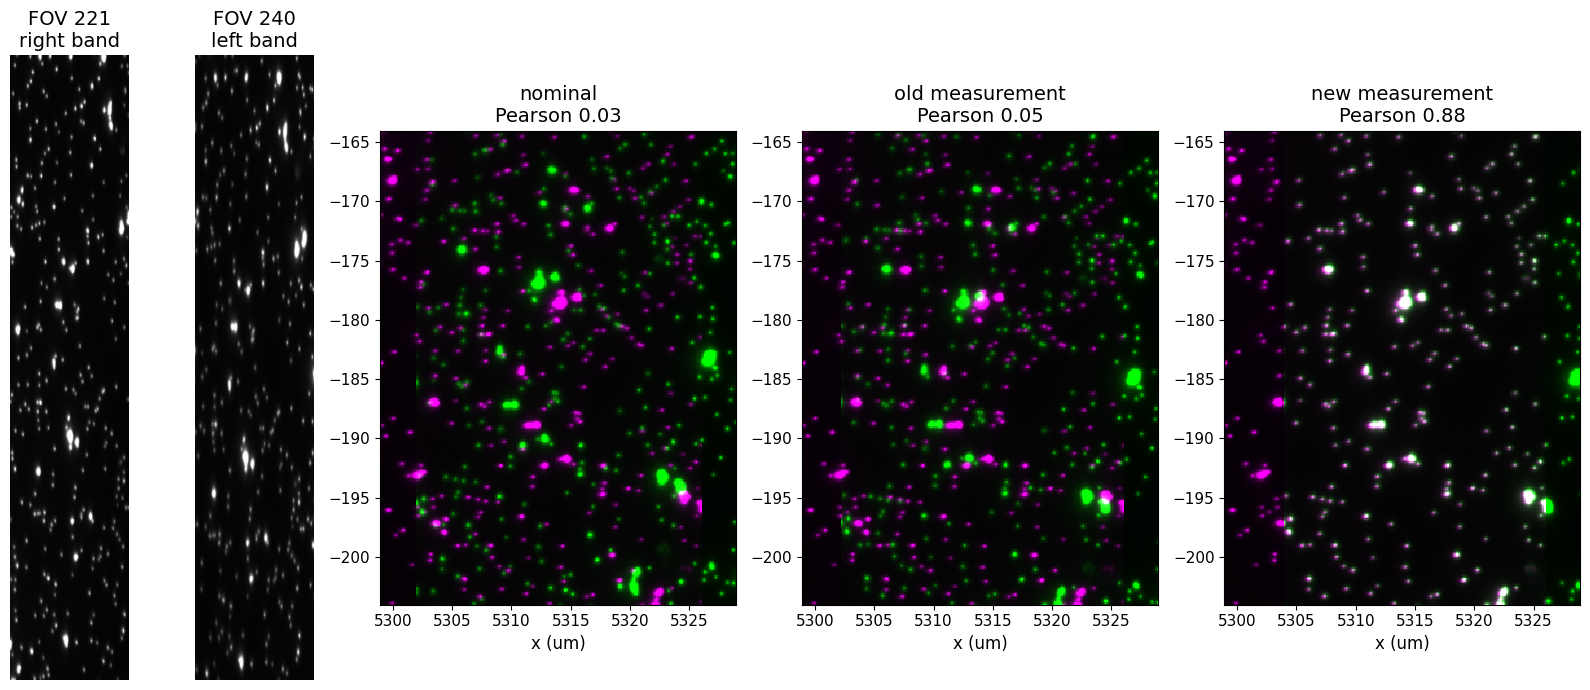

In [8]:
a_band, b_band = L.crop_pair(BEADS[a_f], BEADS[b_f], "right", N_CROP)
fig = plt.figure(figsize=(16, 7))
gs = fig.add_gridspec(1, 5, width_ratios=[1, 1, 3, 3, 3])
for k, (band, name) in enumerate([(a_band, f"FOV {a_f}\nright band"), (b_band, f"FOV {b_f}\nleft band")]):
    ax = fig.add_subplot(gs[k]); lo, hi = np.percentile(band, (1, 99.8))
    ax.imshow(band[800:1250], cmap="gray", vmin=lo, vmax=hi, aspect="auto"); ax.set_title(name); ax.axis("off")
y_mid = nominal[a_f, 1] + FRAME * PX / 2
x_seam = nominal[a_f, 0] + STEP
for k, (name, disp) in enumerate([("nominal", d_nom), ("old measurement", m_old), ("new measurement", m_new)]):
    ax = fig.add_subplot(gs[2 + k])
    pos = {a_f: (*nominal[a_f], 0), b_f: (*(nominal[a_f] + disp), 1)}
    rgb, ext = L.render_tiles({a_f: BEADS[a_f], b_f: BEADS[b_f]}, pos, PX,
                              bounds=(x_seam - 3, y_mid - 20, x_seam + 27, y_mid + 20))
    ax.imshow(rgb, extent=ext, origin="lower", interpolation="nearest")
    rho = L.band_correlation(BEADS[a_f], BEADS[b_f], *np.round(disp / PX).astype(int))
    ax.set_title(f"{name}\nPearson {rho:.2f}"); ax.set_xlabel("x (um)")
fig.tight_layout(); save(fig, "edge_closeup_centre_right")

## 6 — The old cached measurements carry a constant along-axis bias

Same physical edges, old cache vs. this re-measurement. Along-axis = the
component along the step direction; perpendicular = across it.

In [9]:
old_edges = L.Edges(old_df, nominal)
old_lookup = {(a, b): k for k, (a, b) in enumerate(zip(old_edges.i, old_edges.j))}
diff = []
for k in range(len(edges.i)):
    kk = old_lookup.get((edges.i[k], edges.j[k]))
    if kk is None:
        continue
    delta = edges.m[k] - old_edges.m[kk]
    u = edges.d[k] / np.hypot(*edges.d[k])
    diff.append(dict(direction=edges.direction[k], along=delta @ u,
                     perp=delta @ np.array([-u[1], u[0]]), pearson=new_df.pearson[k]))
diff = pd.DataFrame(diff)
good = diff[diff.pearson > 0.3]
print(f"{len(diff)} edges in both sets; {len(good)} with new band Pearson > 0.3")
print(good.groupby("direction")[["along", "perp"]].median().round(3))
print(f"along-axis (new - old): median {good.along.median():.3f} um, IQR "
      f"{good.along.quantile(.25):.3f}..{good.along.quantile(.75):.3f}")
print(f"perpendicular (new - old): median {good.perp.median():.3f} um")
print(f"expected from the crop mismatch: ({N_CROP} - 205) px x {PX} um = {(N_CROP - 205) * PX:.3f} um "
      f"(plus the 0.108 vs {PX} scale on the shift itself)")

894 edges in both sets; 894 with new band Pearson > 0.3
           along   perp
direction              
down       1.832 -0.030
left       1.827 -0.031
right      1.831 -0.030
up         1.833 -0.031
along-axis (new - old): median 1.832 um, IQR 1.828..1.835
perpendicular (new - old): median -0.031 um
expected from the crop mismatch: (222 - 205) px x 0.109 um = 1.853 um (plus the 0.108 vs 0.109 scale on the shift itself)


saved cache/2026_09_25_1336/explanation/figures/stitching_redesign_step_01_measure_edges/old_vs_new_bias.png


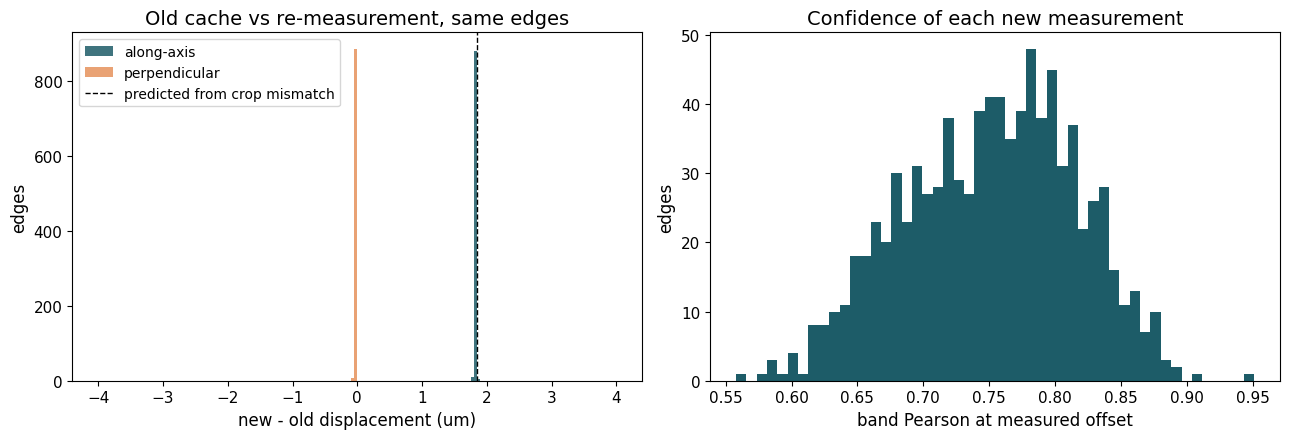

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
bins = np.linspace(-4, 4, 161)
ax[0].hist(good.along, bins=bins, color="#1d5c68", alpha=0.85, label="along-axis")
ax[0].hist(good.perp, bins=bins, color="#e07b39", alpha=0.7, label="perpendicular")
ax[0].axvline((N_CROP - 205) * PX, color="k", ls="--", lw=1, label="predicted from crop mismatch")
ax[0].set_xlabel("new - old displacement (um)"); ax[0].set_ylabel("edges"); ax[0].legend()
ax[0].set_title("Old cache vs re-measurement, same edges")
ax[1].hist(new_df.pearson, bins=50, color="#1d5c68")
ax[1].set_xlabel("band Pearson at measured offset"); ax[1].set_ylabel("edges")
ax[1].set_title("Confidence of each new measurement")
fig.tight_layout(); save(fig, "old_vs_new_bias")

## 7 — Whole grid: what every edge says

In [11]:
def draw_edges(ax, P, idx, values, cmap, vmin, vmax, lw=2.0):
    """Segments between FOV centres for edges idx, coloured by values."""
    half = FRAME * PX / 2
    seg = np.stack([P[edges.i[idx]] + half, P[edges.j[idx]] + half], axis=1)
    lc = LineCollection(seg, cmap=cmap, linewidths=lw)
    lc.set_array(np.asarray(values)); lc.set_clim(vmin, vmax)
    ax.add_collection(lc)
    ax.set_xlim(P[:, 0].min() - 100, P[:, 0].max() + FRAME * PX + 100)
    ax.set_ylim(P[:, 1].min() - 100, P[:, 1].max() + FRAME * PX + 100)
    ax.set_aspect("equal")
    return lc


def mark_nbhd(ax, P, color="k"):
    """Outline the 3x3 neighbourhood on a whole-grid plot."""
    ids = NBHD.ravel()
    x0, y0 = P[ids, 0].min(), P[ids, 1].min()
    x1, y1 = P[ids, 0].max() + FRAME * PX, P[ids, 1].max() + FRAME * PX
    ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec=color, lw=2, ls="--"))


def draw_boxes(ax, P, color, lw=0.6, alpha=1.0):
    for p in P:
        ax.add_patch(mpatches.Rectangle(p, FRAME * PX, FRAME * PX, fill=False, ec=color, lw=lw, alpha=alpha))
    ax.set_xlim(P[:, 0].min() - 100, P[:, 0].max() + FRAME * PX + 100)
    ax.set_ylim(P[:, 1].min() - 100, P[:, 1].max() + FRAME * PX + 100)
    ax.set_aspect("equal")


saved cache/2026_09_25_1336/explanation/figures/stitching_redesign_step_01_measure_edges/grid_residuals_and_confidence.png
              rx            ry       
          median    std median    std
direction                            
down      -3.314  0.030 -2.955  0.353
left      -2.475  0.534  3.330  0.610
right      2.715  0.617 -3.281  1.479
up         3.368  0.229  3.042  0.528


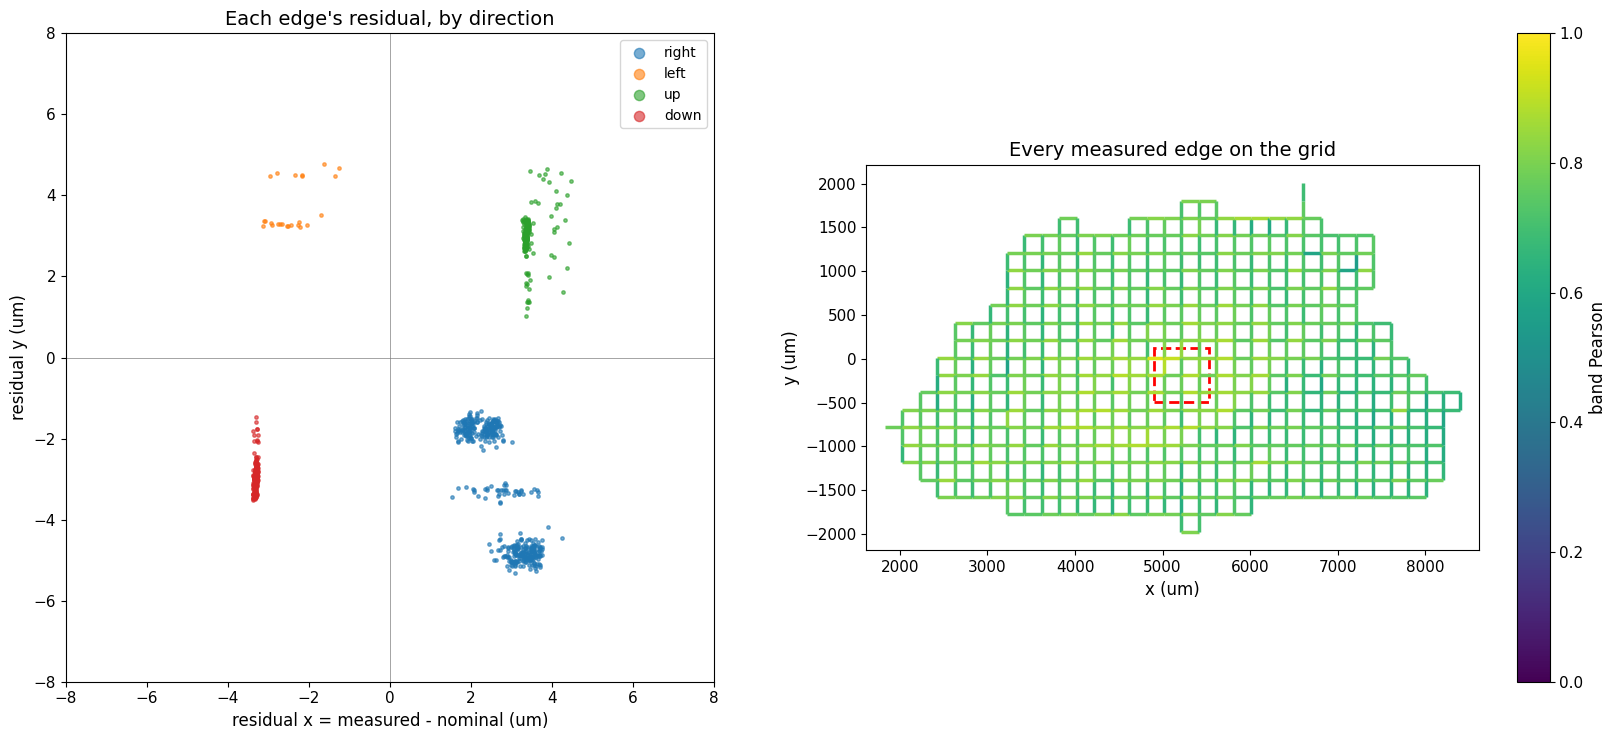

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(17, 7.5))
for dname, col in DIR_COLORS.items():
    s = edges.direction == dname
    ax[0].scatter(edges.r[s, 0], edges.r[s, 1], s=6, color=col, alpha=0.6, label=dname)
ax[0].axhline(0, color="gray", lw=0.5); ax[0].axvline(0, color="gray", lw=0.5)
ax[0].set_xlim(-8, 8); ax[0].set_ylim(-8, 8); ax[0].set_aspect("equal")
ax[0].set_xlabel("residual x = measured - nominal (um)"); ax[0].set_ylabel("residual y (um)")
ax[0].set_title("Each edge's residual, by direction"); ax[0].legend(markerscale=3)
lc = draw_edges(ax[1], nominal, np.arange(len(edges.i)), new_df.pearson, "viridis", 0, 1, lw=2.5)
mark_nbhd(ax[1], nominal, "r")
fig.colorbar(lc, ax=ax[1], label="band Pearson")
ax[1].set_title("Every measured edge on the grid"); ax[1].set_xlabel("x (um)"); ax[1].set_ylabel("y (um)")
fig.tight_layout(); save(fig, "grid_residuals_and_confidence")
print(pd.DataFrame({"direction": edges.direction, "rx": edges.r[:, 0], "ry": edges.r[:, 1]})
      .groupby("direction").agg(["median", "std"]).round(3))

## Notes (numbers quoted by the HTML)

- Geometry: pixel 0.109 um, frame 2048 px (223.23 um), step 199.066 um, nominal overlap 222 px (24.20 um).
- 3x3 neighbourhood: centre FOV 221; rows 202/222/239, 203/221/240, 204/220/241.
- 894 physical edges measured in 337 s (one per edge).
- Edge 221 -> 240: nominal (199.07, 0); new m (201.09, -1.70) um; old m (199.28, -1.70) um.
  Full-overlap Pearson: nominal 0.027, old 0.054, new 0.875.
- New - old, same edges: along-axis median 1.832 um (IQR 1.828..1.835), perpendicular -0.031 um.
  Predicted from the crop mismatch: (222 - 205) px x 0.109 = 1.853 um.
- All 894 new edges have band Pearson > 0.3.
- Residual medians (um): down (-3.314, -2.955), left (-2.475, 3.330), right (2.715, -3.281), up (3.368, 3.042).